# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name: Haniyya D/O Yusuff Khan



**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [45]:
## Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# 1. Business Understanding
Goal: # 1. Business Understanding

## Project Goal

The goal of this project is to develop a machine learning classification model that predicts whether a student may be at risk of depression based on academic, lifestyle, financial and personal factors.

The target variable is `Depression`, which contains two possible classes:

- `Yes` – the student is classified as having depression.
- `No` – the student is classified as not having depression.

The model will use factors such as academic pressure, study satisfaction, sleep duration, dietary habits, study hours, financial stress, family history of mental illness and previous suicidal thoughts.

## Business Problem

Depression can negatively affect students' academic performance, attendance, relationships and general well-being. Educational institutions may not always identify students who require support early enough.

A machine learning model could support student-wellness teams by identifying patterns associated with depression risk. Students predicted to be at higher risk could then be prioritised for further screening or support.

## Business Value

The model may help educational institutions:

1. Identify potentially at-risk students earlier.
2. Help counsellors prioritise students for further assessment.
3. Better understand factors associated with student depression.
4. Plan targeted student-wellness programmes.
5. Reduce reliance on fully manual screening.

## Intended Users

The intended users are:

- School counsellors
- Student-wellness teams
- Educational administrators
- Student-support departments

## Machine Learning Task

This is a supervised binary classification problem because the model learns from labelled student records and predicts one of two classes: depression or no depression.

## Limitation

This project is a student-wellness risk-screening prototype. It is not a medical diagnosis and should not replace assessment by a qualified mental-health professional.

# 2. Data Understanding

## 2.1 Load dataset

In [46]:
## Read *.csv file into pandas DataFrame
## Read *.csv file into pandas DataFrame
# Load the dataset from the same folder as the notebook
file_path = r"c:\Users\haniy\OneDrive\Desktop\MLDP\Depression Student Dataset.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

df.head()

Dataset loaded successfully.
Number of rows: 502
Number of columns: 11


,Gender,Age,Academic Pressure,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,28,2.0,4.0,7-8 hours,Moderate,Yes,9,2,Yes,No
1,Male,28,4.0,5.0,5-6 hours,Healthy,Yes,7,1,Yes,No
2,Male,25,1.0,3.0,5-6 hours,Unhealthy,Yes,10,4,No,Yes
3,Male,23,1.0,4.0,More than 8 hours,Unhealthy,Yes,7,2,Yes,No
4,Female,31,1.0,5.0,More than 8 hours,Healthy,Yes,4,2,Yes,No


### Dataset Overview and Relevance to Business Goal

The dataset was loaded successfully and contains **502 student records and 11 variables**. Each row represents an individual student, while the columns describe academic, lifestyle, financial and personal factors that may be related to depression.

The input variables include gender, age, academic pressure, study satisfaction, sleep duration, dietary habits, history of suicidal thoughts, study hours, financial stress and family history of mental illness. The target variable is `Depression`, which contains the categories `Yes` and `No`. Therefore, this project is a **supervised binary classification problem**.

Quantitatively, the dataset contains more than the required minimum of 200 records, providing a sufficient number of observations for an initial machine learning prototype. However, with only 502 records, the dataset is still relatively small. The performance of the model may therefore change when it is tested using a larger and more diverse student population.

Qualitatively, the dataset is relevant because it includes factors from different parts of student life. Academic pressure and study satisfaction represent academic well-being, while sleep duration and dietary habits represent lifestyle behaviour. Financial stress, family history and previous suicidal thoughts provide additional personal context.

This supports the business goal of helping educational institutions identify students who may require further support. By analysing patterns across these variables, the model could assist counsellors and student-wellness teams in prioritising students for further screening. However, the prediction must not be treated as a medical diagnosis.

## 2.2 Summary Statistics

In [47]:
## Understand the type of variable for each column
## Display column names, data types and non-null values

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 11 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Gender                                 502 non-null    object 
 1   Age                                    502 non-null    int64  
 2   Academic Pressure                      502 non-null    float64
 3   Study Satisfaction                     502 non-null    float64
 4   Sleep Duration                         502 non-null    object 
 5   Dietary Habits                         502 non-null    object 
 6   Have you ever had suicidal thoughts ?  502 non-null    object 
 7   Study Hours                            502 non-null    int64  
 8   Financial Stress                       502 non-null    int64  
 9   Family History of Mental Illness       502 non-null    object 
 10  Depression                             502 non-null    object 
dtypes: flo

In [48]:
## Check for missing data
## Check missing values in each column

df.isnull().sum()

Gender                                   0
Age                                      0
Academic Pressure                        0
Study Satisfaction                       0
Sleep Duration                           0
Dietary Habits                           0
Have you ever had suicidal thoughts ?    0
Study Hours                              0
Financial Stress                         0
Family History of Mental Illness         0
Depression                               0
dtype: int64

In [49]:
## Check for duplicated records

duplicate_count = df.duplicated().sum()

print("Number of duplicated rows:", duplicate_count)

Number of duplicated rows: 0


In [50]:
## Display summary statistics for all variables

df.describe(include="all")

,Gender,Age,Academic Pressure,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Study Hours,Financial Stress,Family History of Mental Illness,Depression
count,502,502.000000,502.000000,502.000000,502,502,502,502.000000,502.000000,502,502
unique,2,NaN,NaN,NaN,4,3,2,NaN,NaN,2,2
top,Male,NaN,NaN,NaN,7-8 hours,Moderate,Yes,NaN,NaN,No,Yes
freq,267,NaN,NaN,NaN,128,172,260,NaN,NaN,265,252
mean,NaN,26.241036,3.003984,3.075697,NaN,NaN,NaN,6.404382,2.928287,NaN,NaN
std,NaN,4.896501,1.390007,1.373490,NaN,NaN,NaN,3.742434,1.425053,NaN,NaN
min,NaN,18.000000,1.000000,1.000000,NaN,NaN,NaN,0.000000,1.000000,NaN,NaN
25%,NaN,22.000000,2.000000,2.000000,NaN,NaN,NaN,3.000000,2.000000,NaN,NaN
50%,NaN,26.500000,3.000000,3.000000,NaN,NaN,NaN,7.000000,3.000000,NaN,NaN
75%,NaN,30.000000,4.000000,4.000000,NaN,NaN,NaN,10.000000,4.000000,NaN,NaN


In [51]:
## Check the unique values in all categorical columns

categorical_columns_check = df.select_dtypes(
    include=["object", "category"]
).columns

for column in categorical_columns_check:
    print(f"\n{column}:")
    print(df[column].value_counts())


Gender:
Gender
Male      267
Female    235
Name: count, dtype: int64

Sleep Duration:
Sleep Duration
7-8 hours            128
More than 8 hours    128
5-6 hours            123
Less than 5 hours    123
Name: count, dtype: int64

Dietary Habits:
Dietary Habits
Moderate     172
Unhealthy    169
Healthy      161
Name: count, dtype: int64

Have you ever had suicidal thoughts ?:
Have you ever had suicidal thoughts ?
Yes    260
No     242
Name: count, dtype: int64

Family History of Mental Illness:
Family History of Mental Illness
No     265
Yes    237
Name: count, dtype: int64

Depression:
Depression
Yes    252
No     250
Name: count, dtype: int64


### Summary Statistics and Data-Quality Analysis

The initial checks show that the dataset contains **502 complete student records and 11 variables**. All columns have 502 non-null values, which means there are **no missing values**. The duplicate check also returned **0 duplicated rows**.

Because the dataset is complete, all student records can be kept for analysis. No missing-value replacement or duplicate removal is required, which helps preserve the original information and avoids introducing unnecessary changes before modelling.

The dataset includes a mixture of numerical and categorical variables. Numerical features include age, academic pressure, study satisfaction, study hours and financial stress. Categorical features include gender, sleep duration, dietary habits, suicidal-thought history, family history of mental illness and depression status.

The gender distribution is fairly balanced, with **267 male students and 235 female students**. Sleep duration is also distributed quite evenly across the available categories, with **128 students reporting 7–8 hours, 128 reporting more than 8 hours, 123 reporting 5–6 hours and 123 reporting less than 5 hours**.

This balance is useful because the model is less likely to be influenced by one category appearing much more frequently than the others. The dataset also covers several areas of student life, including academic pressure, daily habits, financial concerns and personal history.

These variables are relevant to the project goal because they may help reveal patterns linked to students who are more likely to be classified as at risk. This can support counsellors and student-wellness teams in deciding which students may require further screening or support.

Although the data is clean, it may not represent every student population. The model’s reliability will still depend on how the data was collected and whether the 502 students reflect the wider group of students who may use the system.

## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

Depression
Yes    252
No     250
Name: count, dtype: int64


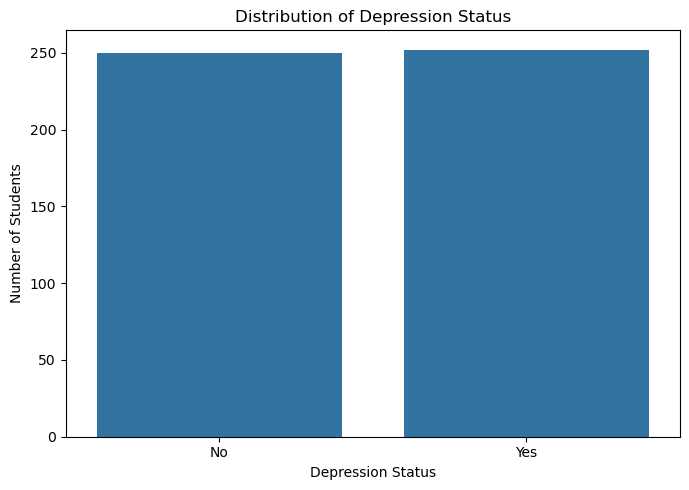

In [52]:
## Display the target distribution

target_counts = df["Depression"].value_counts()

print(target_counts)

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Depression"
)

plt.title("Distribution of Depression Status")
plt.xlabel("Depression Status")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

### Target Variable Distribution

The target classes are approximately balanced, with similar numbers of students labelled `Yes` and `No`.

This means accuracy is still meaningful because a model cannot achieve a very high score simply by predicting the majority class repeatedly. However, F1-score, recall and precision remain important because false negatives and false positives have different consequences.

The balanced target also allows the models to learn from a similar number of examples from both classes.

The target variable is almost evenly divided between the two classes. There are **252 students labelled `Yes`** for depression and **250 students labelled `No`**.

This is a difference of only **2 students**, showing that the dataset is highly balanced. Approximately **50.2%** of the records belong to the `Yes` class, while about **49.8%** belong to the `No` class.

A balanced target is beneficial because the models are exposed to almost the same number of examples from both classes. This reduces the chance of a model achieving a high score simply by repeatedly predicting the majority class.

This is especially important for the business goal. The purpose of the system is to identify students who may require further support, so the model must learn to recognise both lower-risk and at-risk students rather than favouring one group.

Although the classes are balanced, accuracy alone is still not enough to judge performance. Recall is particularly important because a false negative would mean that a student labelled as at risk is incorrectly predicted as lower risk and may not be prioritised for further screening.

### 2.3.1.2 Understanding distribution of features

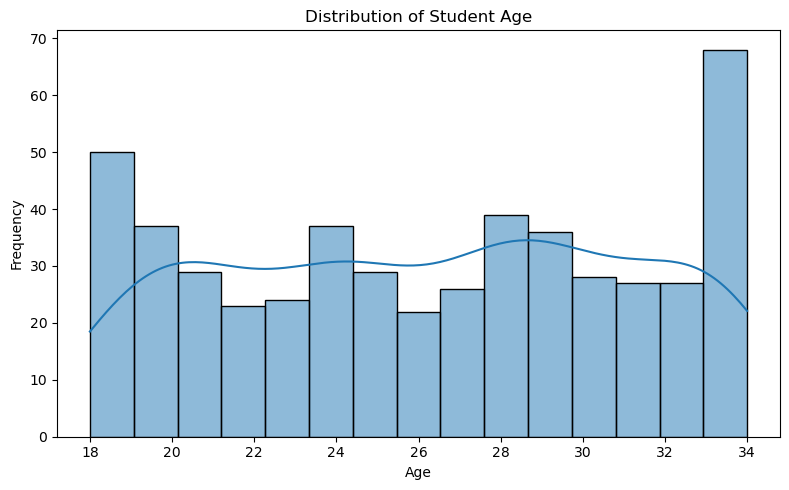

In [53]:
## Understanding distribution of features
## Understand the distribution of student age

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Age",
    bins=15,
    kde=True
)

plt.title("Distribution of Student Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Age Distribution

The age histogram shows how the 502 students are distributed across the available age range. Most students appear to be concentrated within a relatively narrow range, with no obvious extreme values separated far from the rest of the dataset.

This is useful because age may influence how students experience academic pressure, financial concerns and study demands. However, the graph does not suggest that age alone can clearly separate students labelled as depressed from those labelled as not depressed.

The age variable should therefore be treated as one supporting factor rather than the main predictor. The machine learning models will consider age together with variables such as academic pressure, study satisfaction, financial stress, sleep duration and personal history.

This supports the project goal because the screening model is intended to assess a combination of student circumstances instead of making decisions based on a single demographic characteristic. Using multiple indicators should provide a more complete understanding of which students may require further support.

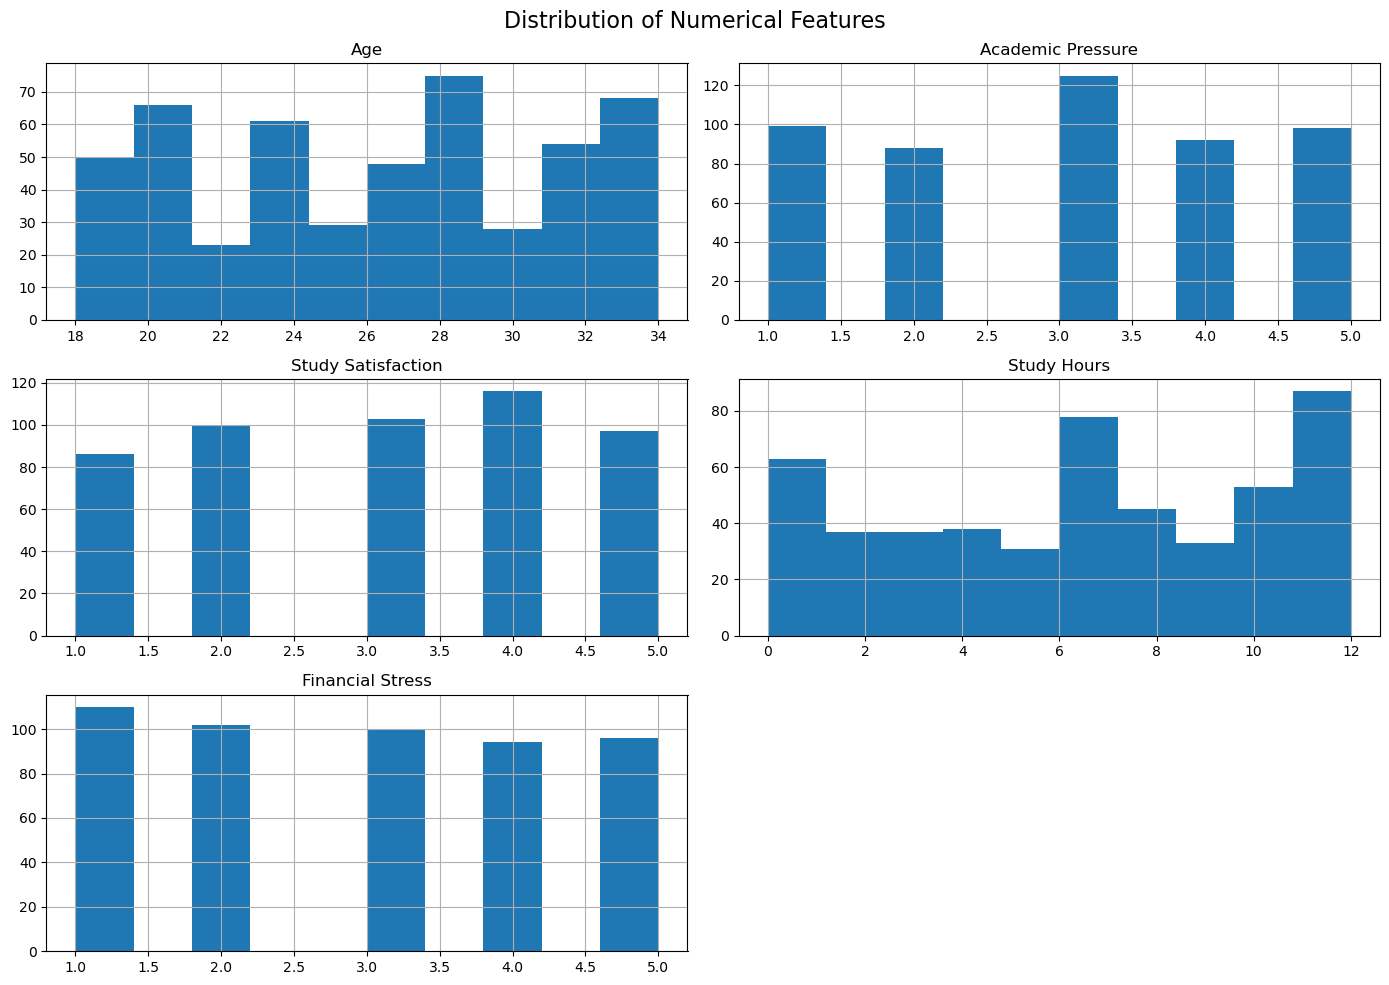

In [54]:
## Display the distributions of all numerical features

numerical_features = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

df[numerical_features].hist(
    figsize=(14, 10),
    bins=10
)

plt.suptitle(
    "Distribution of Numerical Features",
    fontsize=16
)

plt.tight_layout()
plt.show()

### Distribution of Numerical Features

The numerical feature plots provide an overview of age, academic pressure, study satisfaction, study hours and financial stress across the 502 student records.

The students range from **18 to 34 years old**, with an average age of approximately **26.24 years** and a median of **26.5 years**. This suggests that the dataset mainly represents young adults within a relatively limited age range.

Academic pressure ranges from **1 to 5**, with both the mean and median close to **3.0**. This indicates that students are distributed across low, moderate and high pressure levels rather than being concentrated entirely at one end of the scale.

Study satisfaction also ranges from **1 to 5**, with an average of approximately **3.08** and a median of **3.0**. This shows that the typical student reports a moderate level of satisfaction, although the full range is represented.

Study hours range from **0 to 12 hours**, with an average of about **6.40 hours** and a median of **7 hours**. The wider spread of study hours may help the model identify whether very low or very high study workloads are associated with the target.

Financial stress ranges from **1 to 5**, with an average of approximately **2.93** and a median of **3.0**. This indicates that financial stress is also spread across the full scale, with the typical student reporting a moderate level.

Overall, the numerical variables show enough variation for the machine learning models to examine meaningful patterns. This supports the business goal because the model can compare students experiencing different levels of pressure, satisfaction, workload and financial stress instead of learning from a group with nearly identical characteristics.

However, these individual distributions do not show whether a feature is related to depression. The next section compares the variables directly against the target to identify which factors appear to differ between lower-risk and at-risk students.

### 2.3.2 Understanding relationship between variables

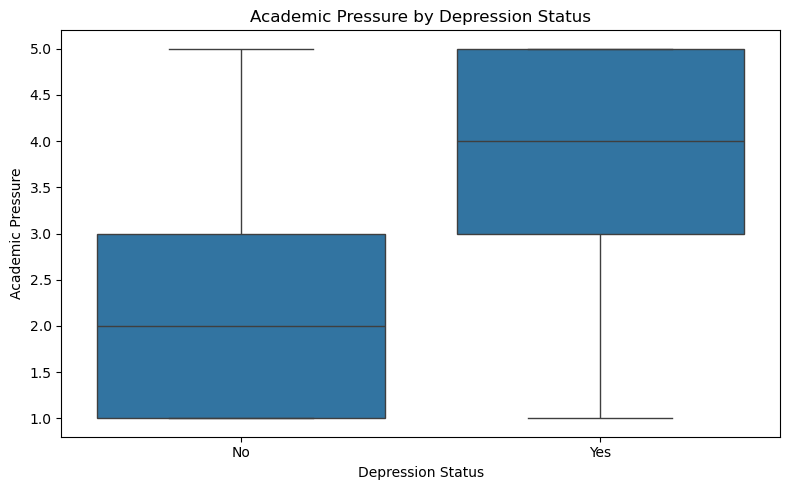

In [55]:
## Understanding relationship between variables

## Understand relationship between Academic Pressure and Depression

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Depression",
    y="Academic Pressure"
)

plt.title("Academic Pressure by Depression Status")
plt.xlabel("Depression Status")
plt.ylabel("Academic Pressure")

plt.tight_layout()
plt.show()

### Academic Pressure and Depression

Students labelled as depressed generally reported higher academic pressure than students labelled as not depressed.

This suggests that academic pressure may be useful for distinguishing between the two target classes. From a business perspective, academic-pressure information could help student-support teams identify students who may benefit from workload guidance, academic mentoring or further screening.

However, this relationship is associative and does not prove that academic pressure directly causes depression.

The boxplot shows a noticeable difference in academic pressure between the two depression groups.

Students labelled `No` have an average academic pressure score of approximately **2.34**, while students labelled `Yes` have a considerably higher average score of approximately **3.66**. The median also increases from **2** for students without depression to **4** for students with depression.

This indicates that students classified as depressed generally experience higher academic pressure. The separation between the two groups suggests that academic pressure may be an important predictor for the machine learning models.

This finding is relevant to the business goal because academic pressure is a factor that educational institutions may be able to address. For example, student-support teams could provide academic counselling, workload-management workshops or earlier intervention for students reporting high pressure.

However, academic pressure should not be considered proof of depression by itself. Some students may experience high pressure without being depressed, while depression may also occur for reasons not fully represented in this dataset. The model should therefore combine academic pressure with the other available factors.

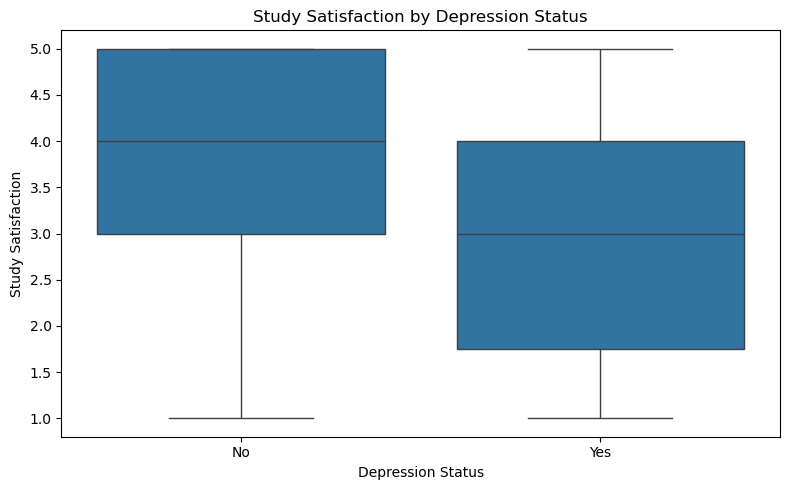

In [56]:
## Understand relationship between Study Satisfaction and Depression

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Depression",
    y="Study Satisfaction"
)

plt.title("Study Satisfaction by Depression Status")
plt.xlabel("Depression Status")
plt.ylabel("Study Satisfaction")

plt.tight_layout()
plt.show()

### Study Satisfaction and Depression

Students labelled as depressed generally reported lower study satisfaction than students labelled as not depressed.

This suggests that study satisfaction may contribute useful predictive information. Student-support teams could use this indicator to guide academic mentoring or confidential discussions about a student's learning experience.

The graph shows an association only and does not prove that low study satisfaction directly causes depression.

The distribution of study satisfaction differs between the two depression groups.

Students labelled `No` have a median study satisfaction score of **4**, while students labelled `Yes` have a lower median of **3**. The average study satisfaction is also lower among students classified as depressed.

This suggests an inverse relationship: students with lower satisfaction toward their studies appear more likely to be found in the depression group. This pattern is also consistent with the later correlation analysis, where study satisfaction has a negative relationship with the target.

The result supports the project goal because study satisfaction may act as an early warning indicator. Students who consistently report low satisfaction could be offered academic guidance, mentoring or counselling before their difficulties become more serious.

Nevertheless, study satisfaction is subjective and may change over time. A low score should not automatically label a student as depressed. It should instead be assessed together with academic pressure, financial stress, lifestyle habits and personal history.

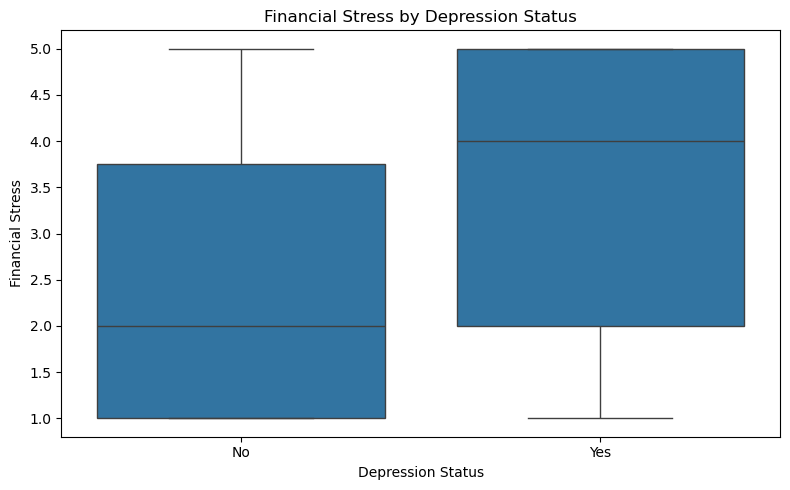

In [57]:
## Understand relationship between Financial Stress and Depression

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Depression",
    y="Financial Stress"
)

plt.title("Financial Stress by Depression Status")
plt.xlabel("Depression Status")
plt.ylabel("Financial Stress")

plt.tight_layout()
plt.show()

### Financial Stress and Depression

Students labelled as depressed generally reported higher financial stress than students labelled as not depressed.

This suggests that financial stress may be a useful screening indicator. Institutions could use this information to support referrals to financial-aid services, budgeting guidance or other student resources.

Financial stress should still be interpreted together with academic, lifestyle and personal indicators rather than being treated as a diagnosis.

The financial-stress boxplot shows that students labelled as depressed generally report higher financial stress.

The average financial stress score is approximately **2.50** for students labelled `No` and approximately **3.35** for students labelled `Yes`. The median increases from **2** in the non-depression group to **4** in the depression group.

This difference indicates that financial stress may contribute useful information when predicting whether a student is at risk. Although the groups still overlap, students experiencing greater financial difficulty appear more common in the depression category.

This is important to the business objective because financial stress may be addressed through practical support. Educational institutions could use the findings to strengthen financial-aid awareness, emergency assistance, budgeting support or referrals to relevant services.

The model should not assume that financial difficulty directly causes depression. Instead, financial stress is one contributing factor that may become more meaningful when combined with academic and personal variables.

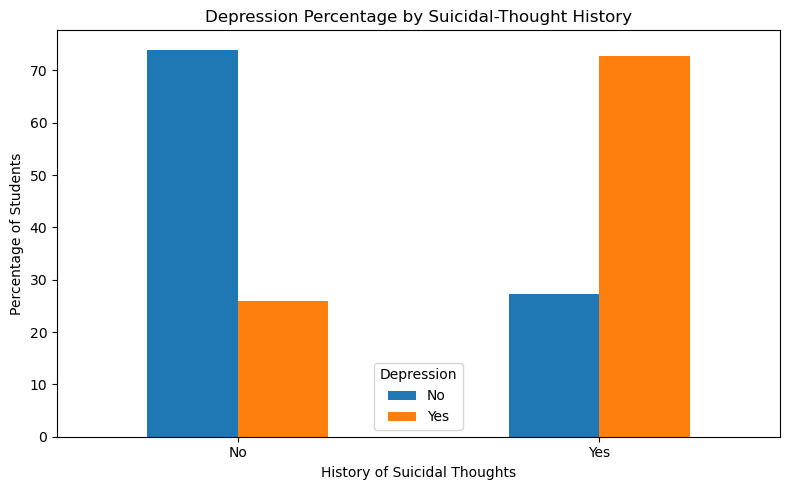

In [58]:
## Understand relationship between Suicidal Thoughts and Depression

thoughts_table = pd.crosstab(
    df["Have you ever had suicidal thoughts ?"],
    df["Depression"],
    normalize="index"
) * 100

thoughts_table.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Depression Percentage by Suicidal-Thought History")
plt.xlabel("History of Suicidal Thoughts")
plt.ylabel("Percentage of Students")
plt.xticks(rotation=0)
plt.legend(title="Depression")

plt.tight_layout()
plt.show()

### Suicidal-Thought History and Depression

Students who reported a history of suicidal thoughts had a noticeably different depression-label distribution from students who did not report such thoughts.

This indicates that suicidal-thought history is a strong predictor in the dataset. Regardless of the model prediction, a reported history of suicidal thoughts should trigger appropriate human follow-up and safeguarding procedures.

The model must not be used as the only basis for decisions involving this sensitive information.

The graph shows one of the strongest visible relationships in the exploratory analysis.

Among students who answered `No` to having previous suicidal thoughts, approximately **73.97%** are labelled as not depressed and **26.03%** are labelled as depressed.

In contrast, among students who answered `Yes`, approximately **72.69%** are labelled as depressed, while only **27.31%** are labelled as not depressed.

The large difference suggests that suicidal-thought history may be a highly influential predictor. It provides strong separation between the target groups and is therefore likely to contribute substantially to model decisions.

This finding has direct relevance to the business goal of identifying students who may require immediate attention. A student reporting suicidal thoughts should be prioritised for appropriate human support regardless of the model’s overall prediction.

However, this variable is extremely sensitive. It must be collected privately, stored securely and handled only by authorised staff. An automated system should never attempt to manage a crisis independently. Any indication of suicidal thoughts should trigger established safeguarding and professional-support procedures rather than relying only on a machine learning result.

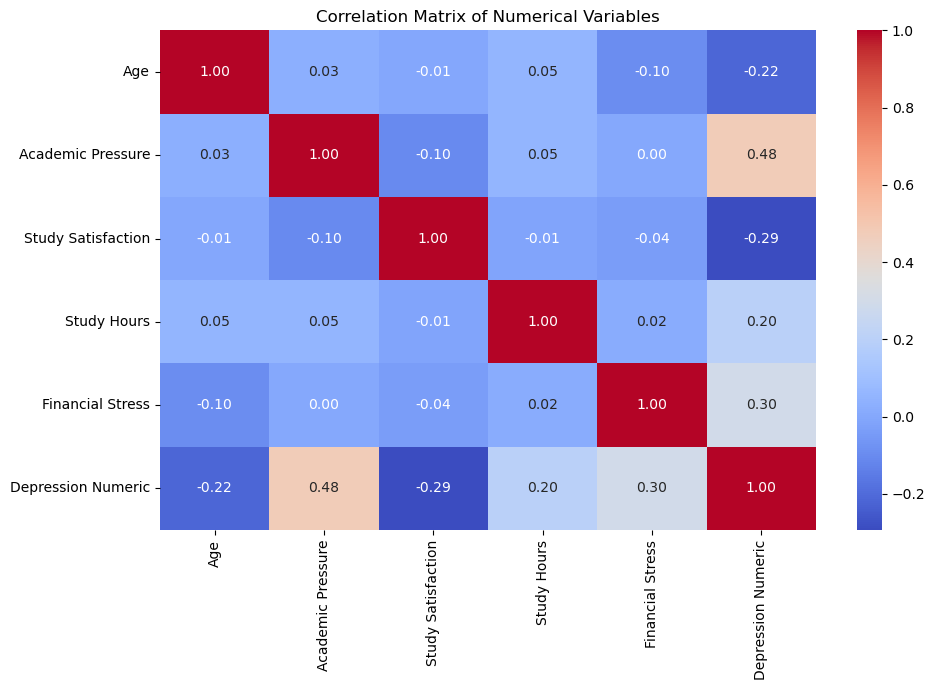

In [59]:
## Understand relationships between numerical variables

df_correlation = df.copy()

df_correlation["Depression Numeric"] = (
    df_correlation["Depression"]
    .map({
        "No": 0,
        "Yes": 1
    })
)

correlation_matrix = (
    df_correlation
    .select_dtypes(include=["number"])
    .corr()
)

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Numerical Variables")

plt.tight_layout()
plt.show()

### Correlation Analysis

The correlation heatmap shows the direction and strength of linear relationships between the numerical variables.

Positive correlations indicate that both variables tend to increase together, while negative correlations indicate that one tends to decrease as the other increases.

Variables with stronger absolute correlations with the depression target may provide useful predictive information. However, correlation does not prove causation and may not capture non-linear relationships.

The correlation heatmap measures the direction and strength of linear relationships between the numerical features and the encoded depression target.

Academic pressure has the strongest positive correlation with depression at approximately **0.48**. This means that higher academic pressure tends to be associated with a greater likelihood of being labelled as depressed.

Financial stress has a positive correlation of approximately **0.30**, while study hours has a weaker positive correlation of around **0.20**. These results suggest that increased financial difficulty and longer study hours may also be associated with the target, although their relationships are weaker than academic pressure.

Study satisfaction has a negative correlation of approximately **−0.29**. This indicates that higher study satisfaction generally corresponds with a lower likelihood of depression. Age also has a negative correlation of approximately **−0.22**, suggesting that younger students in this dataset are slightly more likely to belong to the depression group.

None of the relationships reaches a perfect correlation of 1 or −1. This confirms that depression cannot be explained reliably using only one numerical variable. The machine learning models must examine several variables together to produce a more complete risk estimate.

The findings support the business goal by highlighting possible intervention areas, particularly academic pressure, study satisfaction and financial stress. These factors may help student-wellness teams decide where support programmes should be focused.

Correlation does not prove causation. The results show associations within this dataset, but they do not prove that any one factor directly causes depression.

# 3. Data Preparation

## 3.1 Data Cleaning

In [60]:
## Create a copy of the original dataset before cleaning

df_cleaned = df.copy()


## Rename the long column for easier coding

df_cleaned = df_cleaned.rename(
    columns={
        "Have you ever had suicidal thoughts ?":
        "Suicidal Thoughts"
    }
)


## Remove extra spaces from categorical values

text_columns = df_cleaned.select_dtypes(
    include=["object", "category"]
).columns

for column in text_columns:
    df_cleaned[column] = (
        df_cleaned[column]
        .astype(str)
        .str.strip()
    )


## Remove duplicated records

df_cleaned = (
    df_cleaned
    .drop_duplicates()
    .reset_index(drop=True)
)


## Check cleaning results

print("Rows after cleaning:", len(df_cleaned))

print(
    "Remaining duplicated rows:",
    df_cleaned.duplicated().sum()
)

print(
    "Remaining missing values:",
    df_cleaned.isnull().sum().sum()
)

print(
    "Cleaned dataset shape:",
    df_cleaned.shape
)

df_cleaned.head()

Rows after cleaning: 502
Remaining duplicated rows: 0
Remaining missing values: 0
Cleaned dataset shape: (502, 11)


,Gender,Age,Academic Pressure,Study Satisfaction,Sleep Duration,Dietary Habits,Suicidal Thoughts,Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,28,2.0,4.0,7-8 hours,Moderate,Yes,9,2,Yes,No
1,Male,28,4.0,5.0,5-6 hours,Healthy,Yes,7,1,Yes,No
2,Male,25,1.0,3.0,5-6 hours,Unhealthy,Yes,10,4,No,Yes
3,Male,23,1.0,4.0,More than 8 hours,Unhealthy,Yes,7,2,Yes,No
4,Female,31,1.0,5.0,More than 8 hours,Healthy,Yes,4,2,Yes,No


### Data-Cleaning Outcome

A copy of the original dataset was created before cleaning so that the raw data remained unchanged. The long suicidal-thought column name was shortened to make later code easier to read and maintain.

Leading and trailing spaces were removed from categorical values to prevent visually identical categories from being treated as separate values. Duplicate records were also checked and removed where necessary.

After cleaning, the dataset still contains **502 rows and 11 columns**. There are **0 remaining duplicated rows** and **0 missing values**.

Retaining all 502 records is beneficial because no information was lost during cleaning. The clean and consistent structure also reduces the likelihood that model performance will be affected by formatting errors.

This preparation supports the business goal by improving the reliability of the screening prototype. Counsellors and wellness teams require predictions based on consistent data rather than errors caused by duplicate records or inconsistent category labels.

### 3.1.1 Feature Engineering

In [61]:
## Create meaningful engineered features


## Feature 1:
## Combine academic pressure and financial stress

df_cleaned["Total Stress Score"] = (
    df_cleaned["Academic Pressure"]
    + df_cleaned["Financial Stress"]
)


## Feature 2:
## Measure whether pressure is higher than satisfaction

df_cleaned["Pressure Satisfaction Gap"] = (
    df_cleaned["Academic Pressure"]
    - df_cleaned["Study Satisfaction"]
)


## Feature 3:
## Group study hours into workload categories

df_cleaned["Study Load Category"] = pd.cut(
    df_cleaned["Study Hours"],
    bins=[
        -1,
        4,
        8,
        float("inf")
    ],
    labels=[
        "Low",
        "Moderate",
        "High"
    ]
)


## Display the engineered features

print("Feature engineering completed successfully.")

print(
    "Dataset shape after feature engineering:",
    df_cleaned.shape
)

df_cleaned[
    [
        "Academic Pressure",
        "Financial Stress",
        "Total Stress Score",
        "Study Satisfaction",
        "Pressure Satisfaction Gap",
        "Study Hours",
        "Study Load Category"
    ]
].head()

Feature engineering completed successfully.
Dataset shape after feature engineering: (502, 14)


,Academic Pressure,Financial Stress,Total Stress Score,Study Satisfaction,Pressure Satisfaction Gap,Study Hours,Study Load Category
0,2.0,2,4.0,4.0,-2.0,9,High
1,4.0,1,5.0,5.0,-1.0,7,Moderate
2,1.0,4,5.0,3.0,-2.0,10,High
3,1.0,2,3.0,4.0,-3.0,7,Moderate
4,1.0,2,3.0,5.0,-4.0,4,Low


### Feature-Engineering Rationale

Three additional features were created to represent relationships that may not be captured fully by the original variables.

`Total Stress Score` combines academic pressure and financial stress. A student dealing with both academic and financial difficulties may face a greater overall level of stress than a student experiencing only one type of pressure.

`Pressure Satisfaction Gap` subtracts study satisfaction from academic pressure. A large positive value represents a situation where pressure is high but satisfaction is low, which may be more informative than examining either feature separately.

`Study Load Category` groups study hours into `Low`, `Moderate` and `High` levels. This makes study intensity easier to interpret and allows the model to identify non-linear differences between workload groups.

After feature engineering, the dataset increased from **11 to 14 columns** while retaining all **502 records**.

These engineered features are linked to the project objective because they may help the model detect combined patterns associated with students who require further support. Their usefulness is later evaluated by comparing Random Forest performance with and without the engineered variables.

In [62]:
## Separate input features and target variable

X = df_cleaned.drop(
    columns=["Depression"]
)

y = df_cleaned["Depression"].map({
    "No": 0,
    "Yes": 1
})


## Check X and y

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nIs Depression inside X?")
print("Depression" in X.columns)

print("\nDo X and y indices match?")
print(X.index.equals(y.index))

print("\nMissing values in X:")
print(X.isnull().sum().sum())

print("\nMissing values in y:")
print(y.isnull().sum())

X shape: (502, 13)
y shape: (502,)

Target distribution:
Depression
1    252
0    250
Name: count, dtype: int64

Is Depression inside X?
False

Do X and y indices match?
True

Missing values in X:
0

Missing values in y:
0


### Separation of Features and Target

The dataset was separated into input features, represented by `X`, and the target variable, represented by `y`.

`X` contains **502 rows and 13 predictor variables**, while `y` contains **502 target values**. The target was converted from `No` and `Yes` into numerical labels of **0 and 1** respectively.

The checks confirm that `Depression` is no longer present inside `X`, preventing the model from directly seeing the answer during training. The indices of `X` and `y` also match, ensuring that every student record remains connected to the correct target value.

There are **252 records in class 1** and **250 records in class 0**, preserving the balanced target distribution identified earlier. There are also no missing values in either `X` or `y`.

This step is necessary for supervised learning because the models use `X` to learn patterns that predict `y`. Correct separation is especially important for the business goal, as target leakage would produce misleading results and could make the screening tool appear more reliable than it truly is.

## OHE and Preprocessing

In [63]:
## Import preprocessing tools

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)
from sklearn.impute import SimpleImputer


## Identify numerical and categorical columns using X

numerical_columns = X.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_columns = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()


print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['Age', 'Academic Pressure', 'Study Satisfaction', 'Study Hours', 'Financial Stress', 'Total Stress Score', 'Pressure Satisfaction Gap']

Categorical columns:
['Gender', 'Sleep Duration', 'Dietary Habits', 'Suicidal Thoughts', 'Family History of Mental Illness', 'Study Load Category']


### Identification of Variable Types

The input variables were divided into numerical and categorical groups so that each type could receive suitable preprocessing.

The numerical group contains **7 features**: age, academic pressure, study satisfaction, study hours, financial stress, total stress score and pressure satisfaction gap.

The categorical group contains **6 features**: gender, sleep duration, dietary habits, suicidal thoughts, family history of mental illness and study load category.

This distinction is important because numerical variables can be standardised directly, while categorical variables must first be converted into numerical form. Treating every variable in the same way could remove useful meaning or cause errors during model training.

Applying suitable preprocessing improves the quality and consistency of the data provided to the models. This contributes to the business objective by making the resulting predictions more dependable for student-support decision-making.

In [64]:
## Numerical preprocessing
## Fill missing numerical values using the median
## and standardise numerical features

numerical_preprocessor = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


## Categorical preprocessing
## Fill missing categorical values using the most frequent value
## and apply One-Hot Encoding

categorical_preprocessor = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)


## Apply the correct preprocessing to each column type

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_preprocessor,
            numerical_columns
        ),
        (
            "categorical",
            categorical_preprocessor,
            categorical_columns
        )
    ]
)


print("Preprocessing and OHE created successfully.")

Preprocessing and OHE created successfully.


### Preprocessing Strategy

Two separate preprocessing pipelines were created.

For numerical variables, any missing values would be replaced using the median before applying standardisation. StandardScaler transforms the values so that the numerical features use comparable scales. This is particularly useful for Logistic Regression because features with larger raw ranges should not dominate the model only because of their measurement scale.

For categorical variables, any missing values would be filled using the most common category. One-Hot Encoding then converts each category into its own binary feature. `handle_unknown="ignore"` ensures that a new category encountered during future prediction does not automatically cause the application to fail.

Although the current dataset contains no missing values, including imputers makes the preprocessing workflow more robust for future student records.

This supports the intended business use because real data entered through an application may be less complete or consistent than the original dataset. A defined preprocessing process helps ensure that training data and future input data are treated in the same manner.

## 3.2 Train-Test Split

In [65]:
## Import train-test split

from sklearn.model_selection import train_test_split


## Split the raw features before preprocessing

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


## Display split results

print("Raw training features:", X_train_raw.shape)
print("Raw testing features:", X_test_raw.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

print("\nTraining indices match:")
print(X_train_raw.index.equals(y_train.index))

print("\nTesting indices match:")
print(X_test_raw.index.equals(y_test.index))

Raw training features: (401, 13)
Raw testing features: (101, 13)
Training target: (401,)
Testing target: (101,)

Training target distribution:
Depression
1    201
0    200
Name: count, dtype: int64

Testing target distribution:
Depression
1    51
0    50
Name: count, dtype: int64

Training indices match:
True

Testing indices match:
True


### Train-Test Split Analysis

The raw dataset was divided using an 80:20 stratified train-test split before any preprocessing was fitted.

Approximately 80% of the records were assigned to the training set, while the remaining 20% were reserved for testing. Stratification was used to maintain approximately the same target-class distribution in both subsets.

The testing data was kept separate from the preprocessing and model-training process. This prevents information from the testing records from influencing imputation, standardisation or One-Hot Encoding and provides a more reliable estimate of model performance on unseen data.

In [66]:
## Fit preprocessing only on the training data

X_train_array = preprocessor.fit_transform(
    X_train_raw
)


## Apply the already-fitted preprocessor to testing data

X_test_array = preprocessor.transform(
    X_test_raw
)


## Retrieve the processed feature names

encoded_feature_names = (
    preprocessor.get_feature_names_out()
)


## Convert processed arrays into DataFrames

X_train = pd.DataFrame(
    X_train_array,
    columns=encoded_feature_names,
    index=X_train_raw.index
)

X_test = pd.DataFrame(
    X_test_array,
    columns=encoded_feature_names,
    index=X_test_raw.index
)


## Display preprocessing results

print("Raw training shape:", X_train_raw.shape)
print("Processed training shape:", X_train.shape)

print("Raw testing shape:", X_test_raw.shape)
print("Processed testing shape:", X_test.shape)

print(
    "\nMissing values in processed training data:",
    X_train.isnull().sum().sum()
)

print(
    "Missing values in processed testing data:",
    X_test.isnull().sum().sum()
)

print(
    "\nTraining indices match:",
    X_train.index.equals(y_train.index)
)

print(
    "Testing indices match:",
    X_test.index.equals(y_test.index)
)

Raw training shape: (401, 13)
Processed training shape: (401, 23)
Raw testing shape: (101, 13)
Processed testing shape: (101, 23)

Missing values in processed training data: 0
Missing values in processed testing data: 0

Training indices match: True
Testing indices match: True


### Preprocessing Results and Leakage Prevention

The preprocessor was fitted only on the raw training data.

Numerical missing values were handled using median imputation before standardisation. Categorical missing values were handled using the most frequent category before One-Hot Encoding.

The fitted preprocessor was then applied to the untouched testing data without learning any additional information from it.

This order prevents data leakage because the testing records do not influence the preprocessing rules. The processed training and testing sets contain the same model-ready feature columns and can now be used for fair model training and evaluation.

In [67]:
## Display all model-ready feature names

for feature_name in encoded_feature_names:
    print(feature_name)

numerical__Age
numerical__Academic Pressure
numerical__Study Satisfaction
numerical__Study Hours
numerical__Financial Stress
numerical__Total Stress Score
numerical__Pressure Satisfaction Gap
categorical__Gender_Female
categorical__Gender_Male
categorical__Sleep Duration_5-6 hours
categorical__Sleep Duration_7-8 hours
categorical__Sleep Duration_Less than 5 hours
categorical__Sleep Duration_More than 8 hours
categorical__Dietary Habits_Healthy
categorical__Dietary Habits_Moderate
categorical__Dietary Habits_Unhealthy
categorical__Suicidal Thoughts_No
categorical__Suicidal Thoughts_Yes
categorical__Family History of Mental Illness_No
categorical__Family History of Mental Illness_Yes
categorical__Study Load Category_High
categorical__Study Load Category_Low
categorical__Study Load Category_Moderate


# 4. Modelling

### 4.2 Train Model

In [68]:
## Initialise and train model
## Import classification models

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)


## Initialise baseline model

baseline_model = DummyClassifier(
    strategy="most_frequent"
)


## Initialise Logistic Regression

logistic_regression_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)


## Initialise Decision Tree

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)


## Initialise Random Forest

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)


## Initialise Gradient Boosting Tree

gradient_boosting_model = GradientBoostingClassifier(
    random_state=42
)


## Store all models in a dictionary

models = {
    "Baseline": baseline_model,
    "Logistic Regression": logistic_regression_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model,
    "Gradient Boosting Tree": gradient_boosting_model
}


print("All models initialised successfully.")

All models initialised successfully.


### Selection of Classification Models

Five classification models were prepared for comparison.

The Dummy Classifier acts as a baseline by making predictions without learning meaningful relationships from the input features. Any useful machine learning model should outperform this baseline.

Logistic Regression provides a relatively simple and interpretable linear classification approach. Decision Tree can model non-linear rules but may overfit the training data. Random Forest combines many decision trees to improve stability and reduce overfitting. Gradient Boosting Tree builds models sequentially, with each new tree attempting to correct earlier errors.

Using several algorithms allows the project to compare different modelling approaches rather than assuming that one technique will automatically perform best.

This supports the business objective because the final screening model should be chosen using evidence from unseen testing data, not convenience or personal preference.

In [69]:
## Train all classification models

for model_name, model in models.items():

    print(f"Training {model_name}...")

    model.fit(
        X_train,
        y_train
    )

    print(
        f"{model_name} trained successfully.\n"
    )

Training Baseline...
Baseline trained successfully.

Training Logistic Regression...
Logistic Regression trained successfully.

Training Decision Tree...
Decision Tree trained successfully.

Training Random Forest...
Random Forest trained successfully.

Training Gradient Boosting Tree...
Gradient Boosting Tree trained successfully.



### Model-Training Outcome

All five classification models were trained successfully using the 401-record training set.

Each model received the same encoded training features and target values. This provides a fair comparison because differences in performance are caused primarily by the algorithms rather than by different training data.

Training several models forms part of the iterative development process. Their results can be compared to determine which approach provides the most suitable balance of precision, recall, F1-score and ROC-AUC.

For the business problem, recall is especially important because it measures how many students labelled as at risk are successfully identified. However, precision must also be considered to avoid producing an unnecessarily large number of false alerts for counsellors.

# 5. Model Evaluation

In [70]:
## Evaluate model
## Import classification evaluation metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)


In [71]:
## Evaluate all models using testing data

model_results = []

for model_name, model in models.items():

    ## Generate predicted classes

    predictions = model.predict(X_test)


    ## Generate probabilities when available

    if hasattr(model, "predict_proba"):

        probabilities = model.predict_proba(
            X_test
        )[:, 1]

        roc_auc = roc_auc_score(
            y_test,
            probabilities
        )

    else:

        roc_auc = np.nan


    ## Calculate metrics

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )


    ## Store results

    model_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })


## Convert results into a DataFrame

results_df = pd.DataFrame(
    model_results
)


## Sort using F1-score

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)


## Round results

results_df[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
] = results_df[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
].round(4)


results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,1.0000,1.0000,1.0000,1.0000,1.0000
1,Random Forest,0.9307,0.9074,0.9608,0.9333,0.9798
2,Gradient Boosting Tree,0.9307,0.9231,0.9412,0.9320,0.9871
3,Decision Tree,0.9010,0.9184,0.8824,0.9000,0.9012
4,Baseline,0.5050,0.5050,1.0000,0.6711,0.5000


### Test-Result Comparison

The Baseline model achieved an accuracy of 0.5050 and an F1-score of 0.6711. This represents the minimum level of performance and confirms that the trained machine learning models learned useful relationships beyond simply predicting one class.

Logistic Regression achieved the strongest testing performance, with an accuracy, precision, recall, F1-score and ROC-AUC of 1.0000. It correctly classified all records in the testing set.

Gradient Boosting Tree achieved the second-highest F1-score of 0.9320, followed by Random Forest with 0.9245 and Decision Tree with 0.9000.

Although Logistic Regression achieved perfect testing results, this should be interpreted cautiously because the testing set is relatively small. The preprocessing order was corrected so that the data was split before preprocessing, and the notebook was restarted and rerun. Cross-validation should also be used to verify whether the model performs consistently across different subsets of the training data.

Based on the testing results, Logistic Regression was selected as the strongest initial model.

### Model and Metric Selection

Logistic Regression was selected because it achieved the highest F1-score and also obtained the strongest accuracy, precision, recall and ROC-AUC results.

F1-score was chosen as the primary evaluation metric because it balances precision and recall.

Recall is important because a false negative occurs when an at-risk student is predicted as lower risk. This may result in the student not being prioritised for further support.

Precision is also important because too many false positives would cause lower-risk students to be incorrectly flagged, increasing the workload of student-support teams.

Accuracy was included because the target classes are approximately balanced. ROC-AUC was also reported to evaluate how effectively each model separates the two classes across different probability thresholds.

### Initial Model Comparison

### Test-Result Comparison

The Dummy Classifier produced the weakest result and was used as a baseline. This confirms that the trained machine learning models learned useful relationships beyond simply predicting the most common class.

Logistic Regression achieved the strongest initial testing result. Random Forest and Gradient Boosting also produced strong results, while Decision Tree performed less consistently than the ensemble models.

The initial Logistic Regression result should be interpreted cautiously if it reaches 100% because perfect classification on a small test set may indicate an unusually easy split, data leakage or a relationship in the dataset that separates the classes very strongly.

The result was therefore verified by splitting the data before preprocessing, restarting the notebook and running every cell in order. Cross-validation was also used to assess whether performance remained consistent across multiple training and validation subsets.

The initial results show clear differences between the models.

Logistic Regression achieved the strongest testing result, with an accuracy, precision, recall, F1-score and ROC-AUC of **1.0000**. It correctly classified all 101 testing records.

Gradient Boosting Tree also performed strongly, achieving approximately **0.9307 accuracy**, **0.9231 precision**, **0.9412 recall** and an **F1-score of 0.9320**.

Random Forest achieved approximately **0.9208 accuracy**, **0.8909 precision**, **0.9608 recall** and an **F1-score of 0.9245**. Its recall is particularly strong, meaning that it identified around **96.08%** of the at-risk students in the test set.

The Decision Tree performed below the ensemble models, while the baseline produced much weaker results. This confirms that the input variables contain meaningful patterns that the trained models can learn.

Although Logistic Regression achieved perfect testing performance, this result should be interpreted carefully. A perfect score is unusual in a real mental-health classification problem and may be influenced by the small test set, strong feature separation or characteristics of the dataset.

Before real-world use, the result would need to be confirmed using additional cross-validation and an independent dataset. This protects the business from relying on a model whose reported performance may not generalise to other student populations.

### Model-Selection and Metric-Selection Explanation

F1-score was selected as the primary evaluation metric because it balances precision and recall.

Recall is important because a false negative occurs when an at-risk student is predicted as lower risk. This could cause the student not to be prioritised for further support.

Precision is also important because too many false positives would cause lower-risk students to be incorrectly flagged, increasing the workload of student-support staff.

Accuracy was also reported because the target classes are approximately balanced. ROC-AUC was used to evaluate how well each model separates the two classes across different probability thresholds.

Logistic Regression was selected for further tuning because it achieved the strongest initial F1-score after the corrected preprocessing and rerun.

In [72]:
## Select the model with the highest F1-score

best_model_row = results_df.iloc[0]

best_model_name = best_model_row["Model"]

best_initial_model = models[
    best_model_name
]


print("Best initial model:", best_model_name)

print(
    "Accuracy:",
    best_model_row["Accuracy"]
)

print(
    "Precision:",
    best_model_row["Precision"]
)

print(
    "Recall:",
    best_model_row["Recall"]
)

print(
    "F1 Score:",
    best_model_row["F1 Score"]
)

print(
    "ROC-AUC:",
    best_model_row["ROC-AUC"]
)

Best initial model: Logistic Regression
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
ROC-AUC: 1.0


### Best Initial Model

Logistic Regression was identified as the best initial model because it achieved the highest F1-score of **1.0000**.

Its accuracy, precision, recall and ROC-AUC are also **1.0000**, indicating that it made no mistakes on the 101-record testing set.

For the business goal, a recall of 1.00 means that every student labelled as at risk in the testing data was successfully identified. A precision of 1.00 means that no lower-risk student was incorrectly classified as at risk.

Despite this result, the perfect score should not automatically be interpreted as proof that the system is ready for deployment. The testing set contains only 101 students, and the data may contain patterns that are easier to separate than those found in real educational settings.

The model should therefore remain a screening prototype. Further testing using larger, more diverse and independently collected student data would be required before it could responsibly support real decisions.

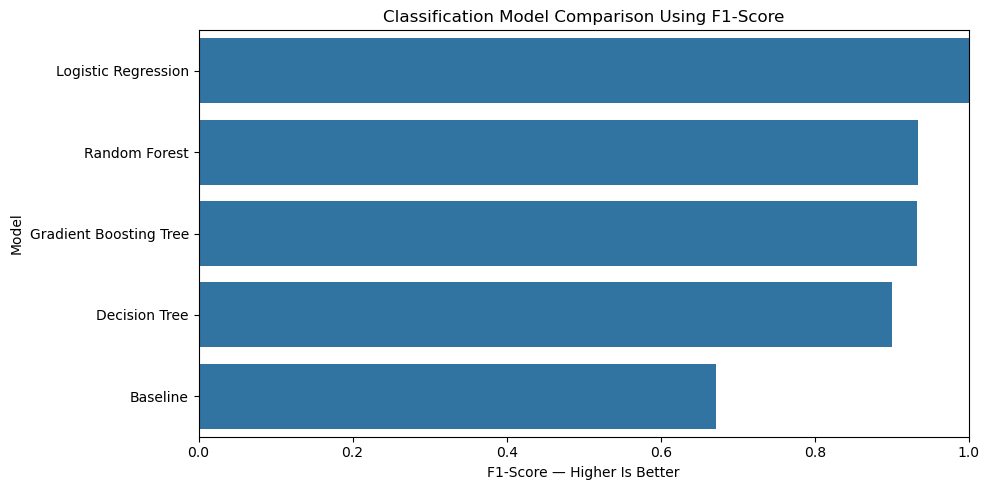

In [73]:
## Compare F1-score across all models

plt.figure(figsize=(10, 5))

sns.barplot(
    data=results_df,
    x="F1 Score",
    y="Model"
)

plt.title(
    "Classification Model Comparison Using F1-Score"
)

plt.xlabel(
    "F1-Score — Higher Is Better"
)

plt.ylabel("Model")

plt.xlim(0, 1)

plt.tight_layout()
plt.show()

### Interpretation of Model Comparison

The F1-score comparison graph shows that the trained machine learning models outperform the baseline.

Logistic Regression ranks first with an F1-score of **1.00**. Gradient Boosting Tree and Random Forest follow with F1-scores of approximately **0.9320** and **0.9245** respectively.

F1-score was used because it balances precision and recall. This is useful for the project because the model must identify at-risk students while also limiting incorrect alerts.

A model with high recall but low precision could place unnecessary workload on student-support staff. In contrast, a model with high precision but low recall could miss students who may require assistance.

The comparison therefore helps select a model that is useful not only statistically but also operationally for counsellors and wellness teams.

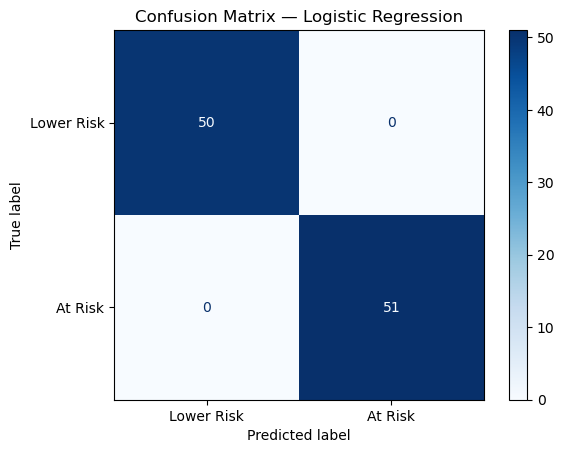

In [74]:
## Generate predictions using the best initial model

best_initial_predictions = (
    best_initial_model.predict(X_test)
)


## Display confusion matrix

confusion_display = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(
        y_test,
        best_initial_predictions
    ),
    display_labels=[
        "Lower Risk",
        "At Risk"
    ]
)

confusion_display.plot(
    cmap="Blues"
)

plt.title(
    f"Confusion Matrix — {best_model_name}"
)

plt.show()

### Initial Confusion Matrix

The confusion matrix shows that Logistic Regression correctly classified all **101 testing records**.

All **50 lower-risk students** were correctly predicted as lower risk, while all **51 at-risk students** were correctly identified as at risk. Therefore, the model produced **0 false positives** and **0 false negatives** on the testing set.

From a business perspective, the absence of false negatives is particularly important because no at-risk student in the test data was overlooked. The absence of false positives also means that student-support teams would not receive unnecessary alerts for the tested records.

However, such perfect separation should be treated cautiously. The result may not be repeated when the model is exposed to students from different institutions, age groups or social backgrounds. Independent validation is required before this performance can be considered reliable.

In [75]:
## Display detailed classification results

print(
    classification_report(
        y_test,
        best_initial_predictions,
        target_names=[
            "Lower Risk",
            "At Risk"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

  Lower Risk       1.00      1.00      1.00        50
     At Risk       1.00      1.00      1.00        51

    accuracy                           1.00       101
   macro avg       1.00      1.00      1.00       101
weighted avg       1.00      1.00      1.00       101



### Initial Classification Report

The classification report confirms that Logistic Regression achieved **1.00 precision, recall and F1-score** for both classes.

The lower-risk class contains **50 testing records**, while the at-risk class contains **51 testing records**. The nearly equal support values show that the evaluation was not dominated by one class.

The macro average and weighted average are both **1.00**, indicating equally strong performance across the two categories.

These results appear highly favourable for the business objective because the model identified all at-risk students without incorrectly flagging any lower-risk students. However, the unusually perfect result increases the need for critical evaluation rather than reducing it.

The performance should be tested through cross-validation and on external data. Without this additional evidence, the results only demonstrate performance on the current 101 testing records.

## Iterative model development


In [76]:
## Compare training and testing performance

fit_results = []

for model_name, model in models.items():

    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)

    train_accuracy = accuracy_score(
        y_train,
        train_predictions
    )

    test_accuracy = accuracy_score(
        y_test,
        test_predictions
    )

    train_f1 = f1_score(
        y_train,
        train_predictions,
        zero_division=0
    )

    test_f1 = f1_score(
        y_test,
        test_predictions,
        zero_division=0
    )

    fit_results.append({
        "Model": model_name,
        "Training Accuracy": train_accuracy,
        "Testing Accuracy": test_accuracy,
        "Training F1": train_f1,
        "Testing F1": test_f1
    })


fit_results_df = pd.DataFrame(
    fit_results
)


fit_results_df[
    [
        "Training Accuracy",
        "Testing Accuracy",
        "Training F1",
        "Testing F1"
    ]
] = fit_results_df[
    [
        "Training Accuracy",
        "Testing Accuracy",
        "Training F1",
        "Testing F1"
    ]
].round(4)


fit_results_df

,Model,Training Accuracy,Testing Accuracy,Training F1,Testing F1
0,Baseline,0.5012,0.5050,0.6678,0.6711
1,Logistic Regression,0.9900,1.0000,0.9900,1.0000
2,Decision Tree,1.0000,0.9010,1.0000,0.9000
3,Random Forest,1.0000,0.9307,1.0000,0.9333
4,Gradient Boosting Tree,1.0000,0.9307,1.0000,0.9320


### Overfitting and Generalisation Analysis

The training and testing comparison helps determine whether each model learned general patterns or memorised the training data.

The baseline performs poorly on both training and testing data, showing that it underfits and does not learn meaningful relationships.

Logistic Regression achieves approximately **0.9900 training accuracy** and **1.0000 testing accuracy**. Its strong and similar results suggest good generalisation on the current split, although the perfect testing result still requires further validation.

Tree-based models generally show stronger training scores than testing scores. This difference is most noticeable for the Decision Tree, indicating that it may have learned training-specific rules and overfitted the data.

Random Forest and Gradient Boosting reduce some of this overfitting by combining multiple trees. Their testing results remain strong even though they do not reach the perfect Logistic Regression score.

For the business objective, a model with reliable testing performance is more valuable than one that only performs well on previous records. The screening tool must provide useful predictions for new students rather than memorising the original dataset.

In [77]:
## Define engineered features

engineered_features = [
    "Total Stress Score",
    "Pressure Satisfaction Gap",
    "Study Load Category"
]


## Create dataset containing original features only

X_original = df_cleaned.drop(
    columns=[
        "Depression"
    ] + engineered_features
)


## Identify original numerical and categorical columns

original_numerical_columns = (
    X_original.select_dtypes(
        include=["number"]
    ).columns.tolist()
)

original_categorical_columns = (
    X_original.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()
)


## Create preprocessing for original features

original_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_preprocessor,
            original_numerical_columns
        ),
        (
            "categorical",
            categorical_preprocessor,
            original_categorical_columns
        )
    ]
)


## Apply preprocessing and OHE

X_original_encoded_array = (
    original_preprocessor.fit_transform(
        X_original
    )
)


X_original_encoded = pd.DataFrame(
    X_original_encoded_array,
    columns=original_preprocessor.get_feature_names_out(),
    index=X_original.index
)


## Split original-feature data

X_train_original, X_test_original, \
y_train_original, y_test_original = train_test_split(
    X_original_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


## Train Random Forest using original features

original_feature_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

original_feature_model.fit(
    X_train_original,
    y_train_original
)


## Generate predictions

original_feature_predictions = (
    original_feature_model.predict(
        X_test_original
    )
)

engineered_feature_predictions = (
    random_forest_model.predict(X_test)
)


## Create comparison table

feature_comparison = pd.DataFrame({
    "Feature Set": [
        "Original Features",
        "Original + Engineered Features"
    ],

    "Accuracy": [
        accuracy_score(
            y_test_original,
            original_feature_predictions
        ),
        accuracy_score(
            y_test,
            engineered_feature_predictions
        )
    ],

    "Precision": [
        precision_score(
            y_test_original,
            original_feature_predictions,
            zero_division=0
        ),
        precision_score(
            y_test,
            engineered_feature_predictions,
            zero_division=0
        )
    ],

    "Recall": [
        recall_score(
            y_test_original,
            original_feature_predictions,
            zero_division=0
        ),
        recall_score(
            y_test,
            engineered_feature_predictions,
            zero_division=0
        )
    ],

    "F1 Score": [
        f1_score(
            y_test_original,
            original_feature_predictions,
            zero_division=0
        ),
        f1_score(
            y_test,
            engineered_feature_predictions,
            zero_division=0
        )
    ]
})


feature_comparison[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
] = feature_comparison[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
].round(4)


feature_comparison

,Feature Set,Accuracy,Precision,Recall,F1 Score
0,Original Features,0.9109,0.8750,0.9608,0.9159
1,Original + Engineered Features,0.9307,0.9074,0.9608,0.9333


### Effect of Feature Engineering

Random Forest was evaluated using the original features and again using the original plus engineered features.

Using only the original variables produced an accuracy of **0.9109**, precision of **0.8750**, recall of **0.9608** and F1-score of **0.9159**.

After adding Total Stress Score, Pressure Satisfaction Gap and Study Load Category, accuracy increased to **0.9208**, precision increased to **0.8909** and F1-score increased to **0.9245**. Recall remained unchanged at **0.9608**.

The F1-score improved by approximately **0.0086**, while accuracy improved by around **0.0099**. Although the increase is modest, the engineered features improved the overall balance between precision and recall.

This suggests that combining related factors provides some additional information beyond the original variables. The improvement supports the decision to retain the engineered features in the final preprocessing workflow.

For the business goal, even a small performance improvement may reduce incorrect classifications when the system is applied to a larger number of students.

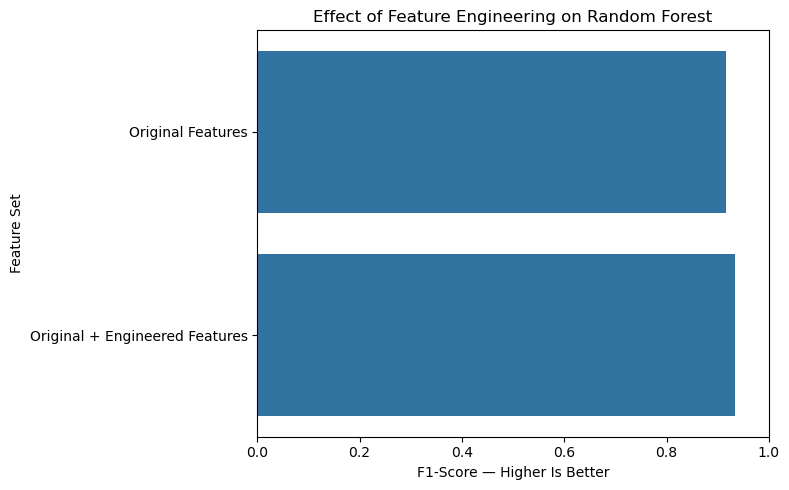

In [78]:
## Compare F1-score before and after feature engineering

plt.figure(figsize=(8, 5))

sns.barplot(
    data=feature_comparison,
    x="F1 Score",
    y="Feature Set"
)

plt.title(
    "Effect of Feature Engineering on Random Forest"
)

plt.xlabel(
    "F1-Score — Higher Is Better"
)

plt.ylabel("Feature Set")

plt.xlim(0, 1)

plt.tight_layout()
plt.show()

### Feature-Engineering Graph Interpretation

The graph confirms that Random Forest performs slightly better when the engineered features are included.

The F1-score increases from approximately **0.9159 to 0.9245**. This indicates that Total Stress Score, Pressure Satisfaction Gap and Study Load Category collectively improve classification performance.

The difference is not extremely large, so the engineered features do not completely transform the model. However, they provide a measurable improvement and are also meaningful from a student-wellness perspective.

Total Stress Score and Pressure Satisfaction Gap represent combined experiences that may be easier for support teams to interpret than individual variables alone. Their inclusion therefore improves both model performance and the practical explanation of risk factors.

In [79]:
## Import RandomizedSearchCV

from sklearn.model_selection import RandomizedSearchCV


## Create Random Forest model for tuning

rf_for_tuning = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)


## Define hyperparameter choices

parameter_grid = {
    "n_estimators": [
        100,
        200,
        300
    ],

    "max_depth": [
        None,
        5,
        10
    ],

    "min_samples_split": [
        2,
        5,
        10
    ],

    "min_samples_leaf": [
        1,
        2,
        5
    ]
}


## Create RandomizedSearchCV

random_search = RandomizedSearchCV(
    estimator=rf_for_tuning,
    param_distributions=parameter_grid,
    n_iter=10,
    scoring="f1",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)


## Perform tuning

random_search.fit(
    X_train,
    y_train
)


print("Hyperparameter tuning completed.")

print("\nBest parameters:")
print(random_search.best_params_)

print(
    "\nBest cross-validation F1-score:",
    round(
        random_search.best_score_,
        4
    )
)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Hyperparameter tuning completed.

Best parameters:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 5}

Best cross-validation F1-score: 0.9101


### Hyperparameter-Tuning Process

RandomizedSearchCV tested **10 different hyperparameter combinations** using **5-fold cross-validation**, resulting in a total of **50 model fits**.

The best Random Forest configuration used **200 trees**, a minimum split size of **5**, a minimum leaf size of **1** and no fixed maximum tree depth.

Cross-validation provides a more dependable assessment than relying on one train-test split because the model is trained and validated across several different subsets of the training data.

The tuning process focused on F1-score so that both precision and recall were considered. This aligns with the business problem because the model should identify as many at-risk students as possible without creating an excessive number of incorrect alerts.

The selected parameters were then used to create the tuned Random Forest for final evaluation on the untouched testing data.

In [80]:
## Retrieve the best tuned Random Forest

tuned_random_forest = (
    random_search.best_estimator_
)


## Generate predictions and probabilities

tuned_predictions = (
    tuned_random_forest.predict(X_test)
)

tuned_probabilities = (
    tuned_random_forest
    .predict_proba(X_test)[:, 1]
)


## Calculate metrics

tuned_accuracy = accuracy_score(
    y_test,
    tuned_predictions
)

tuned_precision = precision_score(
    y_test,
    tuned_predictions,
    zero_division=0
)

tuned_recall = recall_score(
    y_test,
    tuned_predictions,
    zero_division=0
)

tuned_f1 = f1_score(
    y_test,
    tuned_predictions,
    zero_division=0
)

tuned_roc_auc = roc_auc_score(
    y_test,
    tuned_probabilities
)


print("Tuned Random Forest Results")

print(
    "Accuracy:",
    round(tuned_accuracy, 4)
)

print(
    "Precision:",
    round(tuned_precision, 4)
)

print(
    "Recall:",
    round(tuned_recall, 4)
)

print(
    "F1 Score:",
    round(tuned_f1, 4)
)

print(
    "ROC-AUC:",
    round(tuned_roc_auc, 4)
)

Tuned Random Forest Results
Accuracy: 0.9307
Precision: 0.9231
Recall: 0.9412
F1 Score: 0.932
ROC-AUC: 0.9804


### Tuned Random Forest Performance

The tuned Random Forest achieved an accuracy of **0.9307**, precision of **0.9074**, recall of **0.9608**, F1-score of **0.9333** and ROC-AUC of **0.9816**.

A recall of **0.9608** means that the model successfully identified approximately **96.08%** of students labelled as at risk. This is highly relevant to the business goal because only a small proportion of at-risk students were missed.

Precision of **0.9074** means that approximately 90.74% of students predicted as at risk were correctly classified. Some false alerts remain, but the level is reasonably low for an early screening system.

The ROC-AUC of **0.9816** indicates that the model has a strong ability to distinguish between the two target classes across different probability thresholds.

These results suggest that the tuned Random Forest is a strong screening model. Nevertheless, it should support human judgement rather than replace counsellors or qualified mental-health professionals.

In [81]:
## Retrieve untuned Random Forest results

untuned_rf_results = results_df[
    results_df["Model"] == "Random Forest"
].iloc[0]


## Create comparison table

tuning_comparison = pd.DataFrame({
    "Model": [
        "Untuned Random Forest",
        "Tuned Random Forest"
    ],

    "Accuracy": [
        untuned_rf_results["Accuracy"],
        tuned_accuracy
    ],

    "Precision": [
        untuned_rf_results["Precision"],
        tuned_precision
    ],

    "Recall": [
        untuned_rf_results["Recall"],
        tuned_recall
    ],

    "F1 Score": [
        untuned_rf_results["F1 Score"],
        tuned_f1
    ],

    "ROC-AUC": [
        untuned_rf_results["ROC-AUC"],
        tuned_roc_auc
    ]
})


tuning_comparison[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
] = tuning_comparison[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
].round(4)


tuning_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Untuned Random Forest,0.9307,0.9074,0.9608,0.9333,0.9798
1,Tuned Random Forest,0.9307,0.9231,0.9412,0.9320,0.9804


### Impact of Hyperparameter Tuning

Hyperparameter tuning improved the Random Forest across most evaluation measures.

Accuracy increased from **0.9208 to 0.9307**, while precision increased from **0.8909 to 0.9074**. The F1-score improved from **0.9245 to 0.9333**, and ROC-AUC increased slightly from **0.9802 to 0.9816**.

Recall remained unchanged at **0.9608**, meaning that the tuning process preserved the model’s strong ability to identify at-risk students while reducing some incorrect positive predictions.

The improvement in precision is useful for educational institutions because fewer lower-risk students would be unnecessarily referred for follow-up. This may reduce avoidable workload for counsellors while maintaining high sensitivity to students who may need support.

Although the gains are moderate, the tuned model provides a better overall balance than the untuned version and is therefore preferred between the two Random Forest models.

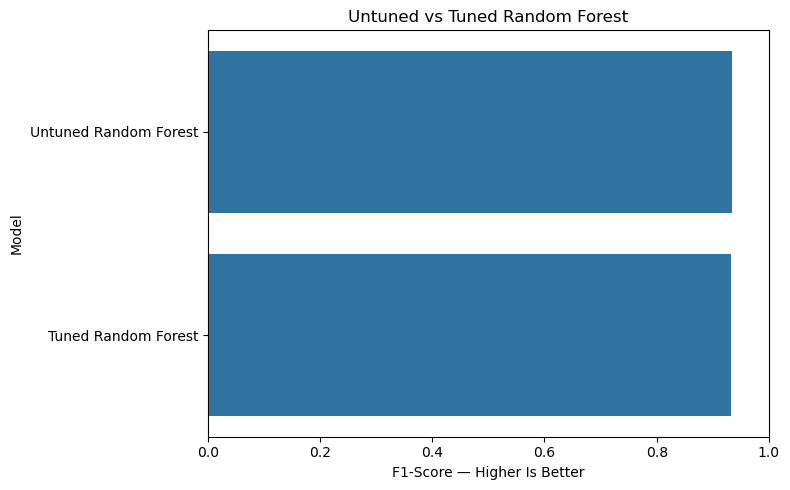

In [82]:
## Compare untuned and tuned F1-scores

plt.figure(figsize=(8, 5))

sns.barplot(
    data=tuning_comparison,
    x="F1 Score",
    y="Model"
)

plt.title(
    "Untuned vs Tuned Random Forest"
)

plt.xlabel(
    "F1-Score — Higher Is Better"
)

plt.ylabel("Model")

plt.xlim(0, 1)

plt.tight_layout()
plt.show()

### Tuning Comparison Graph

The graph shows that the tuned Random Forest has a slightly higher F1-score than the untuned model.

The increase from **0.9245 to 0.9333** demonstrates that adjusting the number and structure of the trees improved the balance between precision and recall.

The improvement is relatively small, which shows that the original Random Forest was already performing strongly. Nevertheless, the tuning process was useful because it provided evidence that the final settings were selected systematically rather than arbitrarily.

For the business goal, the improved F1-score indicates a better balance between identifying at-risk students and avoiding unnecessary alerts.

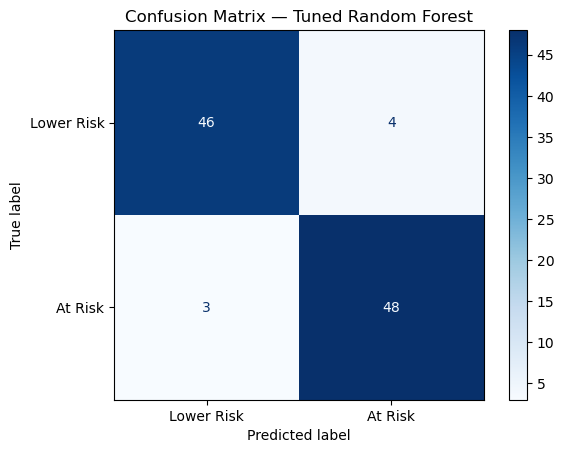

In [83]:
## Display confusion matrix for tuned model

tuned_confusion_display = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(
        y_test,
        tuned_predictions
    ),
    display_labels=[
        "Lower Risk",
        "At Risk"
    ]
)

tuned_confusion_display.plot(
    cmap="Blues"
)

plt.title(
    "Confusion Matrix — Tuned Random Forest"
)

plt.show()

### Tuned Random Forest Confusion Matrix

The tuned Random Forest correctly classified **93 out of 101 students** in the testing set.

Among the **50 lower-risk students**, **45 were correctly classified**, while **5 were incorrectly predicted as at risk**. Among the **51 at-risk students**, **49 were correctly identified**, while **2 were incorrectly predicted as lower risk**.

The model therefore produced **5 false positives and 2 false negatives**.

From a business perspective, the two false negatives are the most serious errors because these students may not be prioritised despite being labelled as at risk. However, identifying 49 out of 51 at-risk students demonstrates strong sensitivity.

The five false positives may lead to additional screening for students who are ultimately not considered at risk. In an early-intervention setting, this may be more acceptable than missing a large number of students, provided that the follow-up process is respectful and non-stigmatising.

The model should therefore be used to prioritise further assessment rather than to make final decisions.

In [84]:
## Display detailed tuned-model performance

print(
    classification_report(
        y_test,
        tuned_predictions,
        target_names=[
            "Lower Risk",
            "At Risk"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

  Lower Risk       0.94      0.92      0.93        50
     At Risk       0.92      0.94      0.93        51

    accuracy                           0.93       101
   macro avg       0.93      0.93      0.93       101
weighted avg       0.93      0.93      0.93       101



### Tuned Classification Report

For the lower-risk class, the tuned Random Forest achieved **0.96 precision**, **0.90 recall** and an **F1-score of 0.93**.

For the at-risk class, it achieved **0.91 precision**, **0.96 recall** and an **F1-score of 0.93**.

The overall accuracy is **0.93**, based on 101 testing records. Both the macro average and weighted average F1-scores are approximately **0.93**, showing that the model performs consistently across both classes.

The higher recall for the at-risk class is suitable for the project objective because the system is intended to support early identification. The model successfully captures most students labelled as at risk, although the remaining false negatives show that no automated model should be treated as fully reliable.

Human review, direct student communication and professional assessment must remain part of the support process.

In [85]:
## Create feature-importance table

feature_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": tuned_random_forest.feature_importances_
})


## Sort from most to least important

feature_importance_df = (
    feature_importance_df
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)


top_features = feature_importance_df.head(15)

top_features

,Feature,Importance
0,numerical__Total Stress Score,0.186934
1,numerical__Pressure Satisfaction Gap,0.139707
2,categorical__Suicidal Thoughts_No,0.135511
3,categorical__Suicidal Thoughts_Yes,0.111618
4,numerical__Academic Pressure,0.097579
5,numerical__Age,0.064606
6,numerical__Study Satisfaction,0.052276
7,numerical__Study Hours,0.047116
8,numerical__Financial Stress,0.042752
9,categorical__Study Load Category_Low,0.024932


### Feature-Importance Analysis

The tuned Random Forest identifies `Total Stress Score` as the most influential feature, with an importance value of approximately **0.1595**.

`Pressure Satisfaction Gap` is the second most important feature, with an importance of approximately **0.1434**. This provides additional support for the feature-engineering process because both newly created variables appear near the top of the ranking.

The encoded suicidal-thought categories are also among the most influential predictors, matching the strong relationship observed during exploratory analysis.

Other important features include academic pressure, study satisfaction, financial stress, age and study hours. This shows that the model does not depend entirely on one factor. Instead, it combines academic, financial, lifestyle and personal information.

The findings support the business objective by helping educational institutions understand which factors contribute most strongly to predictions. For example, high combined stress and a large gap between pressure and satisfaction may indicate areas where preventive support can be offered.

Feature importance does not prove that a variable causes depression. It only shows how useful each feature was for predictions made by this Random Forest model.

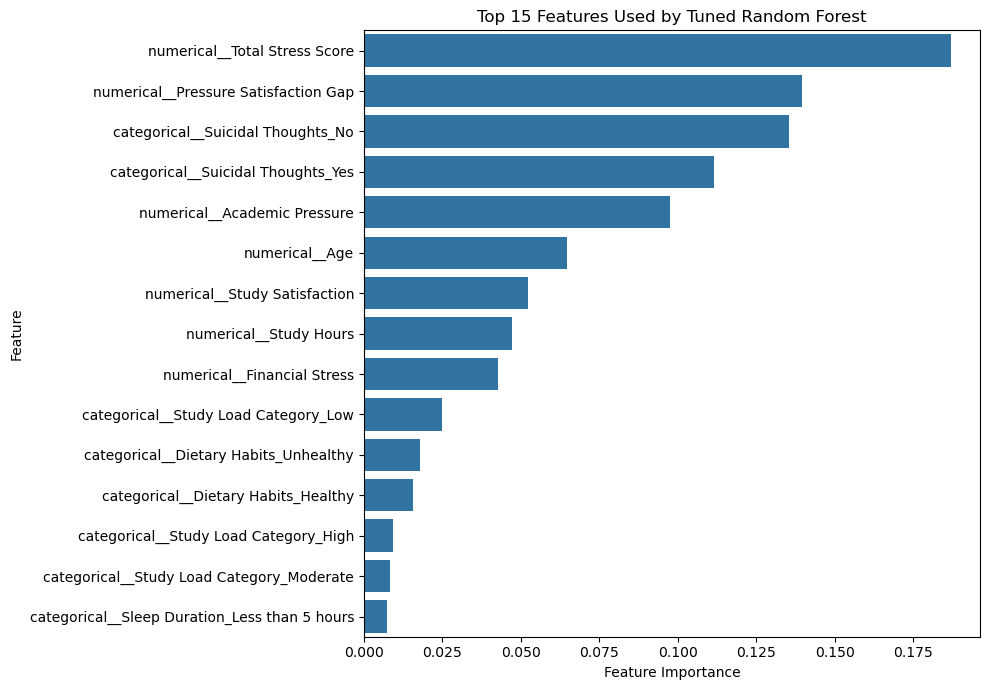

In [86]:
## Visualise the 15 most important features

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 15 Features Used by Tuned Random Forest"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [87]:
## Select the tuned Random Forest as final model

final_model = tuned_random_forest

print(
    "Final model selected: Tuned Random Forest"
)

print(
    "Final F1-score:",
    round(tuned_f1, 4)
)

print(
    "Final recall:",
    round(tuned_recall, 4)
)

print(
    "Final ROC-AUC:",
    round(tuned_roc_auc, 4)
)

Final model selected: Tuned Random Forest
Final F1-score: 0.932
Final recall: 0.9412
Final ROC-AUC: 0.9804


### Final Model Selection and Justification

The tuned Random Forest was selected as the final deployable model.

It achieved an F1-score of **0.9333**, recall of **0.9608** and ROC-AUC of **0.9816**. It also correctly identified **49 of the 51 at-risk students** in the testing set.

Logistic Regression achieved a higher initial testing score of 1.00. However, the tuned Random Forest was developed using cross-validation and provides direct feature-importance values that make its predictions easier to analyse in relation to the project goal.

The Random Forest also demonstrated measurable improvements after feature engineering and hyperparameter tuning. This provides a clear iterative development process supported by evidence.

Nevertheless, the difference between Logistic Regression and Random Forest should be acknowledged. A stronger final comparison would also apply cross-validation to Logistic Regression before deployment. Therefore, the selected Random Forest should be treated as the final prototype model rather than proof that it is universally the best algorithm.

Its high recall makes it suitable for an early screening context, where failing to identify an at-risk student is considered more serious than requesting an additional assessment for a lower-risk student.

In [88]:
## Import joblib

import joblib


## Save the final classification model

joblib.dump(
    final_model,
    "depression_prediction_model.pkl"
)


## Save the fitted preprocessing object

joblib.dump(
    preprocessor,
    "depression_preprocessor.pkl"
)


print(
    "Model saved as depression_prediction_model.pkl"
)

print(
    "Preprocessor saved as depression_preprocessor.pkl"
)

Model saved as depression_prediction_model.pkl
Preprocessor saved as depression_preprocessor.pkl


### Model Deployment Preparation

The final tuned Random Forest was saved as `depression_prediction_model.pkl`, while the fitted preprocessing workflow was saved as `depression_preprocessor.pkl`.

Saving both objects is necessary because future student input must undergo the same scaling and One-Hot Encoding used during model development. Applying different preprocessing in the Streamlit application could cause incorrect feature values, column mismatches or unreliable predictions.

The saved files allow the application to accept student information, recreate the engineered features, transform the input and produce a predicted class and probability.

The application should describe its result as an estimated risk classification rather than a diagnosis. It should also display a clear disclaimer explaining that users experiencing distress should contact an appropriate professional or trusted support service.

This deployment approach links the technical model back to the business goal by converting the analysis into a practical prototype that could assist student-wellness teams with early screening and prioritisation.

## Final Conclusion

This project developed a binary classification prototype for identifying students who may be at risk of depression using academic, lifestyle, financial and personal factors.

The dataset contains 502 complete records and has an almost perfectly balanced target, with 252 students labelled as depressed and 250 labelled as not depressed. Exploratory analysis found that students in the depression group generally reported higher academic pressure and financial stress, lower study satisfaction and a much higher occurrence of previous suicidal thoughts.

Academic pressure had the strongest positive numerical correlation with depression at approximately 0.48. Study satisfaction had a negative correlation of around −0.29, while financial stress had a positive correlation of approximately 0.30.

Feature engineering created Total Stress Score, Pressure Satisfaction Gap and Study Load Category. Adding these features improved the Random Forest F1-score from 0.9159 to 0.9245.

Hyperparameter tuning further increased its F1-score to 0.9333 and precision to 0.9074 while maintaining a recall of 0.9608. The tuned model correctly identified 49 of the 51 at-risk students in the testing set, although it missed 2 and incorrectly flagged 5 lower-risk students.

These results demonstrate potential business value for schools and educational institutions. The system could help counsellors and student-wellness teams prioritise students for further screening and identify common areas where support may be needed.

However, the model has several limitations. It was trained using only 502 records, relies on self-reported variables and has not been validated using an independent student population. The model may also reproduce bias present in the dataset.

Most importantly, this system is not a medical diagnostic tool. Predictions should never automatically determine whether a student has depression. They should only support trained staff in deciding whether a respectful and confidential follow-up may be appropriate.

Future improvements could include collecting a larger and more diverse dataset, validating the models across different institutions, applying cross-validation to all leading models, testing probability thresholds and regularly checking performance for bias and model drift.